# Gold Commodity Price Prediction (4-Year Analysis)

This notebook presents a complete project workflow with a clean, reproducible process:

1. Download 4 years of gold futures data from Yahoo Finance (`GC=F`).
2. Perform EDA and feature engineering for time-series forecasting.
3. Train and compare multiple models for next-day prediction.
4. Evaluate on holdout data and generate future forecasts.
5. Export artifacts for the final report.

In [1]:
import json
import warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    xgboost_available = True
except Exception:
    xgboost_available = False

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Download the latest ~4 years of gold futures prices.
end_date = datetime.now(timezone.utc).date()
start_date = end_date - timedelta(days=365 * 4 + 40)

raw = yf.download(
    "GC=F",
    start=start_date.isoformat(),
    end=(end_date + timedelta(days=1)).isoformat(),
    progress=False,
    auto_adjust=False,
)

if raw.empty:
    raise ValueError("No data downloaded from Yahoo Finance for GC=F.")

# Handle multi-index columns from yfinance.
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [c[0].lower() for c in raw.columns]
else:
    raw.columns = [c.lower() for c in raw.columns]

data = raw[["open", "high", "low", "close", "volume"]].copy().sort_index()
data = data[~data.index.duplicated(keep="last")]

print(f"Rows: {len(data):,}")
print(f"Date range: {data.index.min().date()} -> {data.index.max().date()}")
data.tail()

Rows: 1,033
Date range: 2022-03-07 -> 2026-04-15


,open,high,low,close,volume
Date,,,,,
2026-04-09,4711.000000,4799.100098,4711.000000,4792.200195,1277
2026-04-10,4745.899902,4791.000000,4744.899902,4761.899902,812
2026-04-13,4704.000000,4742.399902,4704.000000,4742.399902,32
2026-04-14,4770.100098,4841.600098,4770.100098,4825.000000,32
2026-04-15,4862.700195,4895.399902,4834.600098,4839.200195,30903


,count,mean,std,min,25%,50%,75%,max
open,1033.0,2587.292934,921.077253,1620.400024,1920.699951,2182.699951,3091.000000,5415.700195
high,1033.0,2603.379768,932.217271,1623.300049,1927.099976,2196.199951,3132.500000,5586.200195
low,1033.0,2571.539979,907.771814,1615.099976,1914.500000,2177.199951,3066.800049,5301.600098
close,1033.0,2587.857111,920.045324,1623.300049,1919.199951,2182.500000,3097.000000,5318.399902
volume,1033.0,4100.129719,20237.160263,0.000000,96.000000,341.000000,941.000000,202373.000000


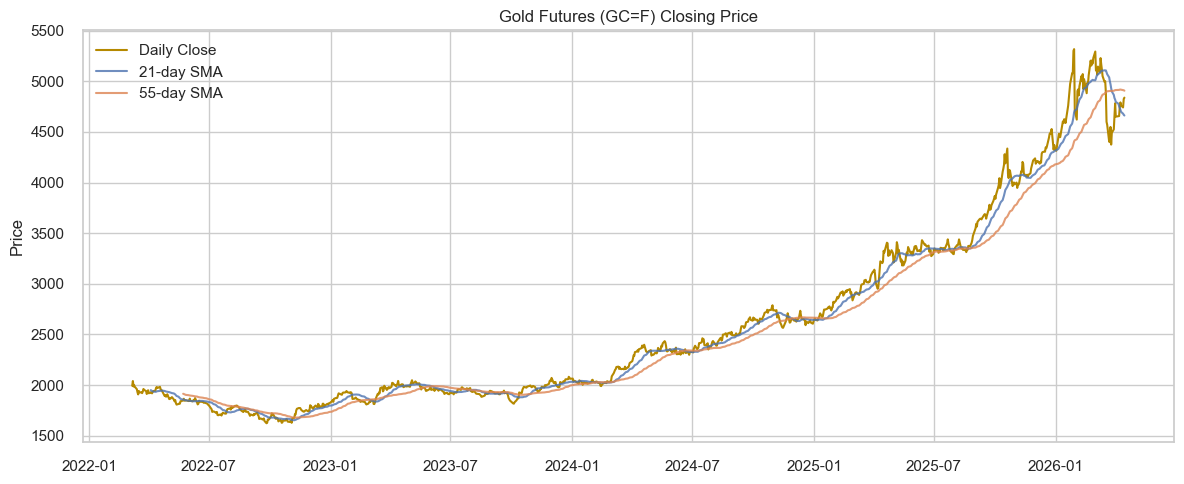

In [3]:
# Basic EDA
display(data.describe().T)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["close"], label="Daily Close", color="#b58900")
ax.plot(data["close"].rolling(21).mean(), label="21-day SMA", alpha=0.8)
ax.plot(data["close"].rolling(55).mean(), label="55-day SMA", alpha=0.8)
ax.set_title("Gold Futures (GC=F) Closing Price")
ax.set_ylabel("Price")
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "gold_close_history.png", dpi=160)
plt.show()

In [4]:
def add_technical_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["ret_1"] = out["close"].pct_change(1)
    out["ret_3"] = out["close"].pct_change(3)
    out["ret_5"] = out["close"].pct_change(5)
    out["ret_10"] = out["close"].pct_change(10)

    for lag in [1, 2, 3, 5, 10, 21]:
        out[f"lag_close_{lag}"] = out["close"].shift(lag)
        out[f"lag_ret_{lag}"] = out["ret_1"].shift(lag)

    for w in [5, 10, 21, 55]:
        out[f"sma_{w}"] = out["close"].rolling(w).mean()
        out[f"ema_{w}"] = out["close"].ewm(span=w, adjust=False).mean()

    out["vol_10"] = out["ret_1"].rolling(10).std()
    out["vol_21"] = out["ret_1"].rolling(21).std()

    delta = out["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-10)
    out["rsi_14"] = 100 - (100 / (1 + rs))

    ema_12 = out["close"].ewm(span=12, adjust=False).mean()
    ema_26 = out["close"].ewm(span=26, adjust=False).mean()
    out["macd"] = ema_12 - ema_26
    out["macd_signal"] = out["macd"].ewm(span=9, adjust=False).mean()

    out["range_hl"] = (out["high"] - out["low"]) / out["close"]
    out["range_oc"] = (out["open"] - out["close"]) / out["close"]

    out["dow"] = out.index.dayofweek
    out["month"] = out.index.month
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7.0)
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7.0)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12.0)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12.0)

    # Predict next-day return, then convert to next-day close for evaluation.
    out["target_ret_next"] = out["close"].pct_change().shift(-1)

    return out


featured = add_technical_features(data)
model_data = featured.dropna().copy()

target_col = "target_ret_next"
feature_cols = [c for c in model_data.columns if c != target_col]

X = model_data[feature_cols]
y = model_data[target_col]
idx = model_data.index
feature_medians = X.median(numeric_only=True)

print(f"Model rows after feature engineering: {len(model_data):,}")
print(f"Feature count: {len(feature_cols)}")

Model rows after feature engineering: 978
Feature count: 42


In [5]:
# Chronological split: train / validation / test
n = len(model_data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

idx_train = idx[:train_end]
idx_val = idx[train_end:val_end]
idx_test = idx[val_end:]

print("Train:", X_train.shape, idx_train.min().date(), "->", idx_train.max().date())
print("Val:  ", X_val.shape, idx_val.min().date(), "->", idx_val.max().date())
print("Test: ", X_test.shape, idx_test.min().date(), "->", idx_test.max().date())

Train: (684, 42) 2022-05-23 -> 2025-02-11
Val:   (147, 42) 2025-02-12 -> 2025-09-11
Test:  (147, 42) 2025-09-12 -> 2026-04-14


In [6]:
def to_next_close(current_close: np.ndarray, predicted_return: np.ndarray) -> np.ndarray:
    return current_close * (1.0 + predicted_return)


def score_close_predictions(
    y_true_ret: np.ndarray,
    y_pred_ret: np.ndarray,
    current_close: np.ndarray,
) -> dict:
    true_close = to_next_close(current_close, y_true_ret)
    pred_close = to_next_close(current_close, y_pred_ret)

    mae = mean_absolute_error(true_close, pred_close)
    rmse = np.sqrt(mean_squared_error(true_close, pred_close))
    mape = np.mean(np.abs((true_close - pred_close) / true_close)) * 100
    r2 = r2_score(true_close, pred_close)
    true_dir = np.where(y_true_ret >= 0, 1, -1)
    pred_dir = np.where(y_pred_ret >= 0, 1, -1)
    directional_acc = (true_dir == pred_dir).mean() * 100

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAPE_%": float(mape),
        "R2": float(r2),
        "Directional_Accuracy_%": float(directional_acc),
    }

In [7]:
# Candidate models
models = {
    "Ridge": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=5.0)),
        ]
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=700,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

if xgboost_available:
    xgb_candidates = [
        dict(n_estimators=500, learning_rate=0.03, max_depth=3, subsample=0.8, colsample_bytree=0.8),
        dict(n_estimators=700, learning_rate=0.03, max_depth=4, subsample=0.85, colsample_bytree=0.9),
        dict(n_estimators=900, learning_rate=0.02, max_depth=4, subsample=0.8, colsample_bytree=0.8),
        dict(n_estimators=600, learning_rate=0.05, max_depth=3, subsample=0.9, colsample_bytree=0.9),
    ]

    best_xgb = None
    best_xgb_rmse = np.inf
    for params in xgb_candidates:
        mdl = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            reg_lambda=1.0,
            **params,
        )
        mdl.fit(X_train, y_train)
        val_pred_ret = mdl.predict(X_val)
        val_metrics = score_close_predictions(
            y_true_ret=y_val.values,
            y_pred_ret=val_pred_ret,
            current_close=X_val["close"].values,
        )
        if val_metrics["RMSE"] < best_xgb_rmse:
            best_xgb_rmse = val_metrics["RMSE"]
            best_xgb = mdl

    models["XGBoost"] = best_xgb

# Validation comparison
val_rows = []
baseline_val_pred_ret = np.zeros_like(y_val.values)
val_rows.append(
    {
        "Model": "Naive (No-Change)",
        **score_close_predictions(y_val.values, baseline_val_pred_ret, X_val["close"].values),
    }
)

for name, model in models.items():
    # XGBoost may already be prefit from candidate loop; refit for consistency
    model.fit(X_train, y_train)
    pred_ret = model.predict(X_val)
    val_rows.append(
        {
            "Model": name,
            **score_close_predictions(y_val.values, pred_ret, X_val["close"].values),
        }
    )

val_results = pd.DataFrame(val_rows).sort_values("RMSE").reset_index(drop=True)
display(val_results)

,Model,MAE,RMSE,MAPE_%,R2,Directional_Accuracy_%
0,Naive (No-Change),30.851699,41.009509,0.949721,0.953693,57.142857
1,Ridge,31.217724,42.207085,0.962377,0.950949,49.659864
2,RandomForest,32.675125,43.962414,1.005780,0.946784,40.136054


In [8]:
# Retrain on train+val, then evaluate on holdout test
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

test_rows = []
test_predictions = {}

baseline_test_pred_ret = np.zeros_like(y_test.values)
baseline_metrics = score_close_predictions(y_test.values, baseline_test_pred_ret, X_test["close"].values)
test_rows.append({"Model": "Naive (No-Change)", **baseline_metrics})
test_predictions["Naive (No-Change)"] = to_next_close(X_test["close"].values, baseline_test_pred_ret)

for name, model in models.items():
    model.fit(X_trainval, y_trainval)
    pred_ret = model.predict(X_test)
    pred_close = to_next_close(X_test["close"].values, pred_ret)
    test_predictions[name] = pred_close
    test_rows.append(
        {
            "Model": name,
            **score_close_predictions(y_test.values, pred_ret, X_test["close"].values),
        }
    )

test_results = pd.DataFrame(test_rows).sort_values("RMSE").reset_index(drop=True)
display(test_results)

best_model_name = test_results.iloc[0]["Model"]
non_naive = test_results[test_results["Model"] != "Naive (No-Change)"]
forecast_model_name = non_naive.iloc[0]["Model"] if not non_naive.empty else best_model_name

print(f"Best holdout model (lowest RMSE): {best_model_name}")
print(f"Forecast model (best non-naive): {forecast_model_name}")

,Model,MAE,RMSE,MAPE_%,R2,Directional_Accuracy_%
0,Naive (No-Change),64.097985,96.497927,1.412004,0.954204,60.544218
1,Ridge,65.478000,97.650131,1.443329,0.953104,51.020408
2,RandomForest,67.984062,99.939662,1.501179,0.950879,48.979592


Best holdout model (lowest RMSE): Naive (No-Change)
Forecast model (best non-naive): Ridge


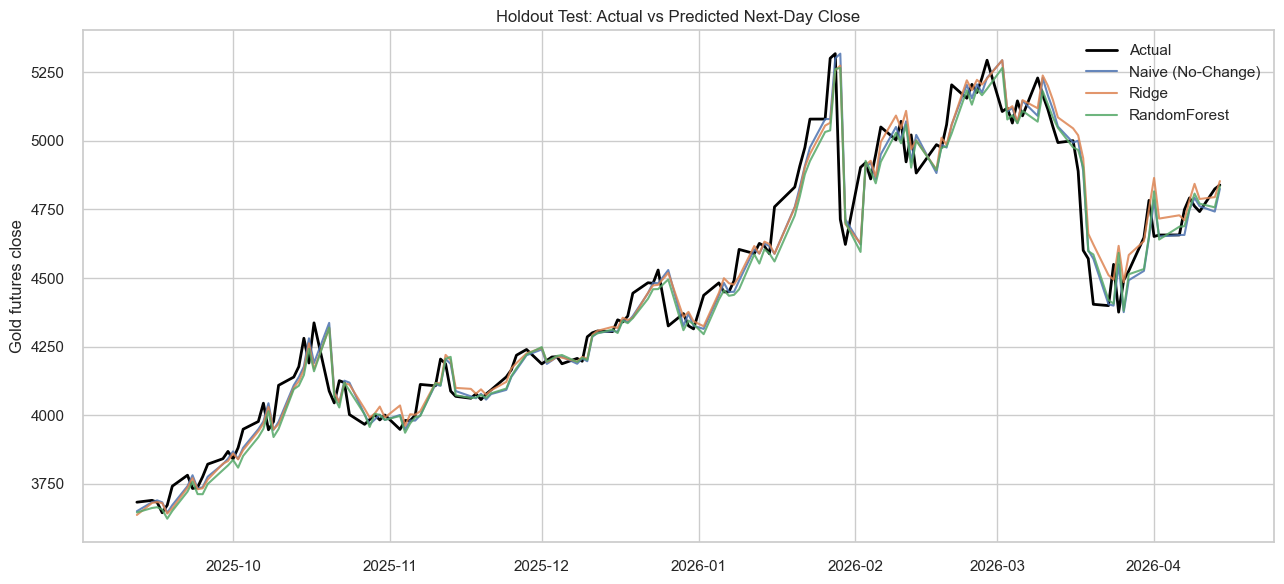

In [9]:
# Plot test predictions for all models
y_test_close = to_next_close(X_test["close"].values, y_test.values)
test_plot = pd.DataFrame({"date": idx_test, "actual_close": y_test_close}).set_index("date")

for name, preds in test_predictions.items():
    test_plot[f"pred_{name}"] = preds

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(test_plot.index, test_plot["actual_close"], label="Actual", color="black", linewidth=2)
for col in [c for c in test_plot.columns if c.startswith("pred_")]:
    ax.plot(test_plot.index, test_plot[col], label=col.replace("pred_", ""), alpha=0.85)
ax.set_title("Holdout Test: Actual vs Predicted Next-Day Close")
ax.set_ylabel("Gold futures close")
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "test_actual_vs_pred.png", dpi=170)
plt.show()

# Keep a CSV with predictions
test_plot.to_csv(ARTIFACT_DIR / "test_predictions.csv")

In [10]:
# Recursive multi-step forecast (next 30 business days)
horizon = 30
history = data.copy()
future_records = []


def build_feature_row(hist_df: pd.DataFrame) -> pd.Series:
    feat = add_technical_features(hist_df).iloc[-1]
    return feat.drop(labels=["target_ret_next"], errors="ignore")


if forecast_model_name == "Naive (No-Change)":
    forecast_model = None
else:
    forecast_model = models[forecast_model_name]

current_date = history.index[-1]
current_close = history["close"].iloc[-1]

for _ in range(horizon):
    next_date = current_date + pd.offsets.BDay(1)
    feature_row = build_feature_row(history).reindex(feature_cols)
    feature_row = feature_row.fillna(feature_medians).fillna(0.0)

    if forecast_model is None:
        pred_ret = 0.0
    else:
        pred_ret = float(forecast_model.predict(feature_row.to_frame().T)[0])

    next_close = float(current_close * (1.0 + pred_ret))

    # Create synthetic OHLCV row from predicted close for recursive feature updates.
    new_row = pd.DataFrame(
        {
            "open": [current_close],
            "high": [max(current_close, next_close)],
            "low": [min(current_close, next_close)],
            "close": [next_close],
            "volume": [history["volume"].tail(21).mean()],
        },
        index=[next_date],
    )

    history = pd.concat([history, new_row], axis=0)
    future_records.append({"date": next_date, "predicted_close": next_close, "predicted_return": pred_ret})

    current_date = next_date
    current_close = next_close

future_df = pd.DataFrame(future_records).set_index("date")
display(future_df.head())

,predicted_close,predicted_return
date,,
2026-04-16,4869.529307,0.006267
2026-04-17,4896.420585,0.005522
2026-04-20,4897.343737,0.000189
2026-04-21,4911.461708,0.002883
2026-04-22,4911.452920,-0.000002


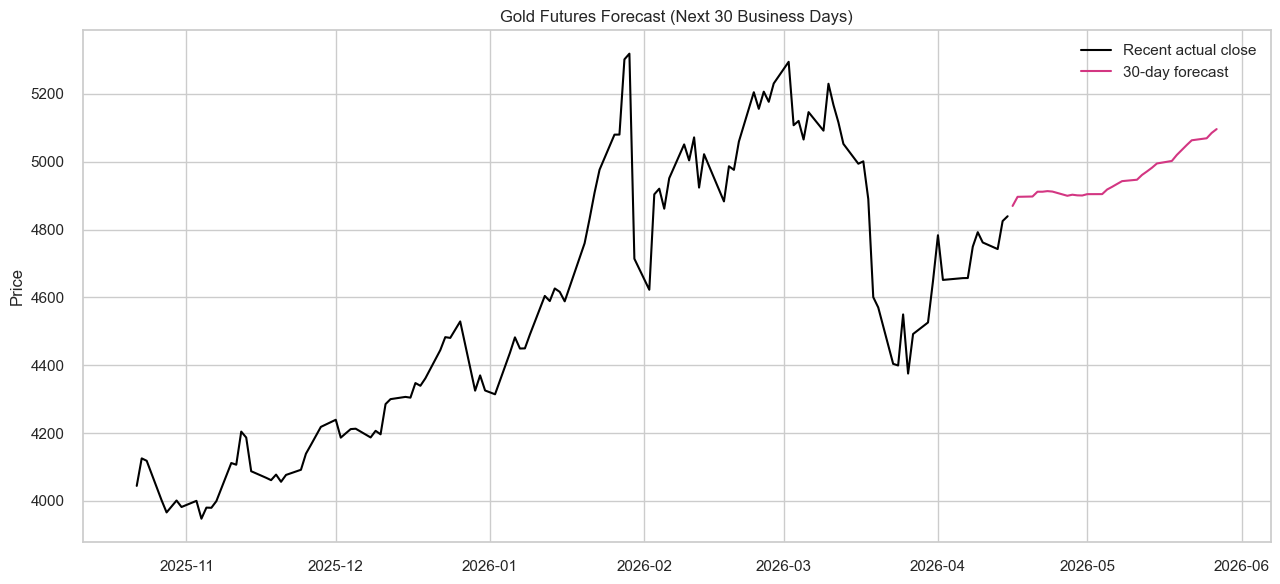

In [11]:
fig, ax = plt.subplots(figsize=(13, 6))
recent = data["close"].tail(120)
ax.plot(recent.index, recent.values, label="Recent actual close", color="black")
ax.plot(future_df.index, future_df["predicted_close"], label="30-day forecast", color="#d33682")
ax.set_title(f"Gold Futures Forecast (Next {len(future_df)} Business Days)")
ax.set_ylabel("Price")
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "forecast_next_30d.png", dpi=170)
plt.show()

future_df.to_csv(ARTIFACT_DIR / "future_forecast.csv")

In [12]:
# Export machine-readable metrics for report generation
payload = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "ticker": "GC=F",
    "date_range": {
        "start": str(data.index.min().date()),
        "end": str(data.index.max().date()),
    },
    "raw_rows": int(len(data)),
    "model_rows": int(len(model_data)),
    "best_model": best_model_name,
    "forecast_model": forecast_model_name,
    "validation_results": val_results.to_dict(orient="records"),
    "test_results": test_results.to_dict(orient="records"),
    "latest_close": float(data["close"].iloc[-1]),
    "forecast_last_value": float(future_df["predicted_close"].iloc[-1]),
}

(ARTIFACT_DIR / "metrics_summary.json").write_text(json.dumps(payload, indent=2))
val_results.to_csv(ARTIFACT_DIR / "validation_results.csv", index=False)
test_results.to_csv(ARTIFACT_DIR / "test_results.csv", index=False)

print("Artifacts written to:", ARTIFACT_DIR.resolve())
print("Best model:", best_model_name)
print("Forecast model:", forecast_model_name)

Artifacts written to: /Users/naveenthumati/Gold_Price_Prediction_Project/artifacts
Best model: Naive (No-Change)
Forecast model: Ridge


## Outcome
This notebook now provides an end-to-end, reproducible project:

- online data ingestion from Yahoo Finance,
- careful time-series feature engineering,
- model benchmarking with proper chronological split,
- holdout evaluation and forecast generation,
- exported artifacts for reporting.